In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [44]:
csv_path = Path("../data/processed/df_full.csv")
parquet_path = Path("../data/processed/df_full.parquet")

if not parquet_path.exists():
    print("Conversion CSV → Parquet…")
    df = pd.read_csv(csv_path)
    df.to_parquet(parquet_path, engine="fastparquet")
else:
    print("Parquet déjà présent, conversion ignorée.")

Parquet déjà présent, conversion ignorée.


In [45]:
df = pd.read_parquet("../data/processed/df_full.parquet", engine="fastparquet")

In [46]:
df.head(10)

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry
5,2,17794,6,1,202279,prior,3,5,9,8.0,Carrots,83,4,fresh vegetables,produce
6,2,40141,7,1,202279,prior,3,5,9,8.0,Original Unflavored Gelatine Mix,105,13,doughs gelatins bake mixes,pantry
7,2,1819,8,1,202279,prior,3,5,9,8.0,All Natural No Stir Creamy Almond Butter,88,13,spreads,pantry
8,2,43668,9,0,202279,prior,3,5,9,8.0,Classic Blend Cole Slaw,123,4,packaged vegetables fruits,produce
9,3,33754,1,1,205970,prior,16,5,17,12.0,Total 2% with Strawberry Lowfat Greek Strained...,120,16,yogurt,dairy eggs


In [47]:
df.shape

(33819106, 15)

In [48]:
df.isna().sum()

order_id                        0
product_id                      0
add_to_cart_order               0
reordered                       0
user_id                         0
eval_set                        0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
product_name                    0
aisle_id                        0
department_id                   0
aisle                           0
department                      0
dtype: int64

In [49]:
df.aisle.value_counts()

aisle
fresh fruits                  3792661
fresh vegetables              3568630
packaged vegetables fruits    1843806
yogurt                        1507583
packaged cheese               1021462
                               ...   
eye ear care                     9522
baby bath body care              8909
baby accessories                 8466
beauty                           6455
frozen juice                     5147
Name: count, Length: 134, dtype: int64

## Exploratory Data Analysis
### Customers' temporal purchasing habits

In [50]:
df.order_hour_of_day.value_counts().sort_index()

order_hour_of_day
0      228031
1      121412
2       72660
3       53759
4       55714
5       91909
6      302642
7      928239
8     1787359
9     2550569
10    2874905
11    2852701
12    2732599
13    2778054
14    2810918
15    2780731
16    2647695
17    2186409
18    1714445
19    1317576
20    1017958
21     831183
22     662053
23     419585
Name: count, dtype: int64

In [51]:
df["department"] = df["department"].astype("category")
df["reordered"] = df["reordered"].astype("category")

In [52]:
df["order_dow"].value_counts().sort_index()

order_dow
0    6533692
1    5871834
2    4378360
3    3998498
4    3942696
5    4386443
6    4707583
Name: count, dtype: int64

#### When do customers order the most?

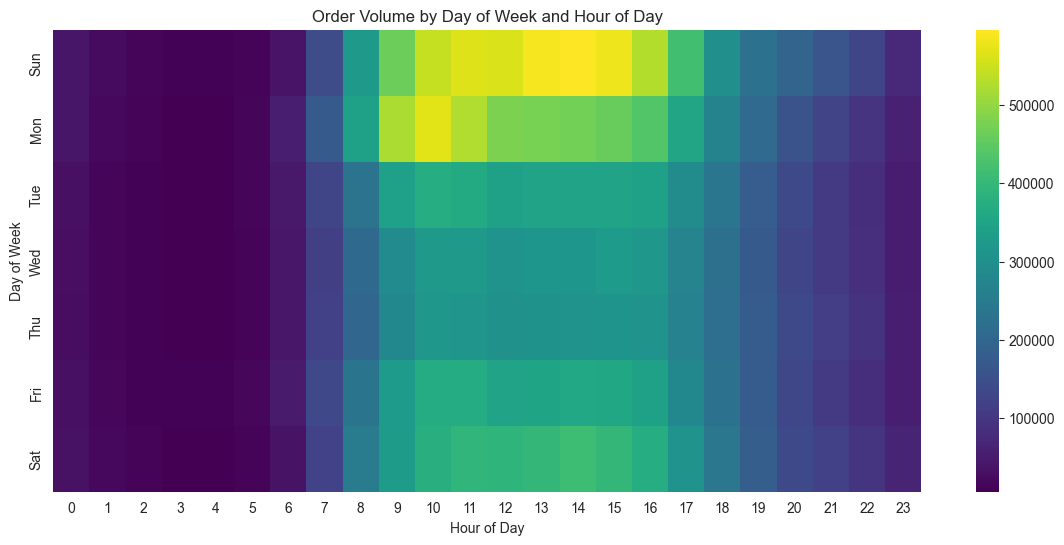

In [53]:
heatmap_data = (
    df.groupby(["order_dow", "order_hour_of_day"])
      .size()
      .reset_index(name="count")
)
heatmap_pivot = heatmap_data.pivot(
    index="order_dow",
    columns="order_hour_of_day",
    values="count"
)

day_labels = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
heatmap_pivot.index = day_labels

plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_pivot,
    cmap="viridis"
)

plt.title("Order Volume by Day of Week and Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()

### AXIS 1 — Loyalty by department
#### Which departments foster the most loyalty?

C:\Users\natha\AppData\Local\Temp\ipykernel_21972\3114159742.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\natha\AppData\Local\Temp\ipykernel_21972\3114159742.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




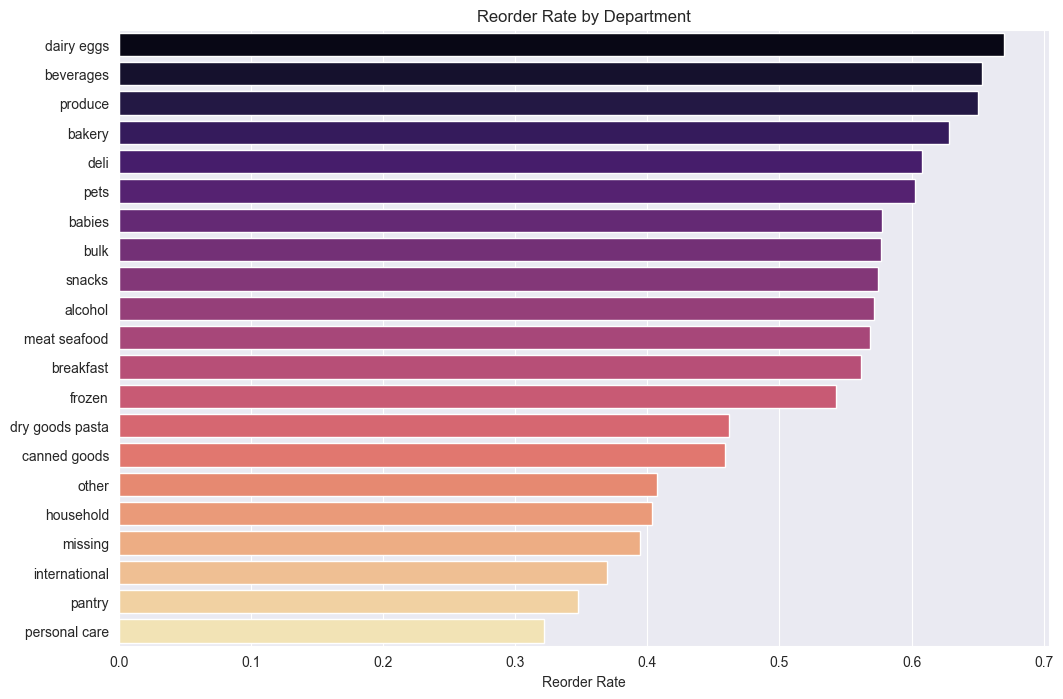

In [54]:
df['reordered'] = df['reordered'].astype(int)

dept_loyalty = (
    df.groupby("department")
      .agg(
          total_items=("reordered", "size"),
          reordered_items=("reordered", "sum")
      )
      .assign(reorder_rate=lambda x: x["reordered_items"] / x["total_items"])
      .reset_index()
      .sort_values("reorder_rate", ascending=False)
)
plt.figure(figsize=(12,8))
sns.barplot(
    data=dept_loyalty,
    y="department",
    x="reorder_rate",
    order=dept_loyalty["department"],
    palette="magma"
)

plt.title("Reorder Rate by Department")
plt.xlabel("Reorder Rate")
plt.ylabel("")
plt.show()

### AXIS 2 — Products that promote loyalty
#### Which products account for a disproportionate share of loyalty?

threshold value : 18.0


C:\Users\natha\AppData\Local\Temp\ipykernel_21972\927928759.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




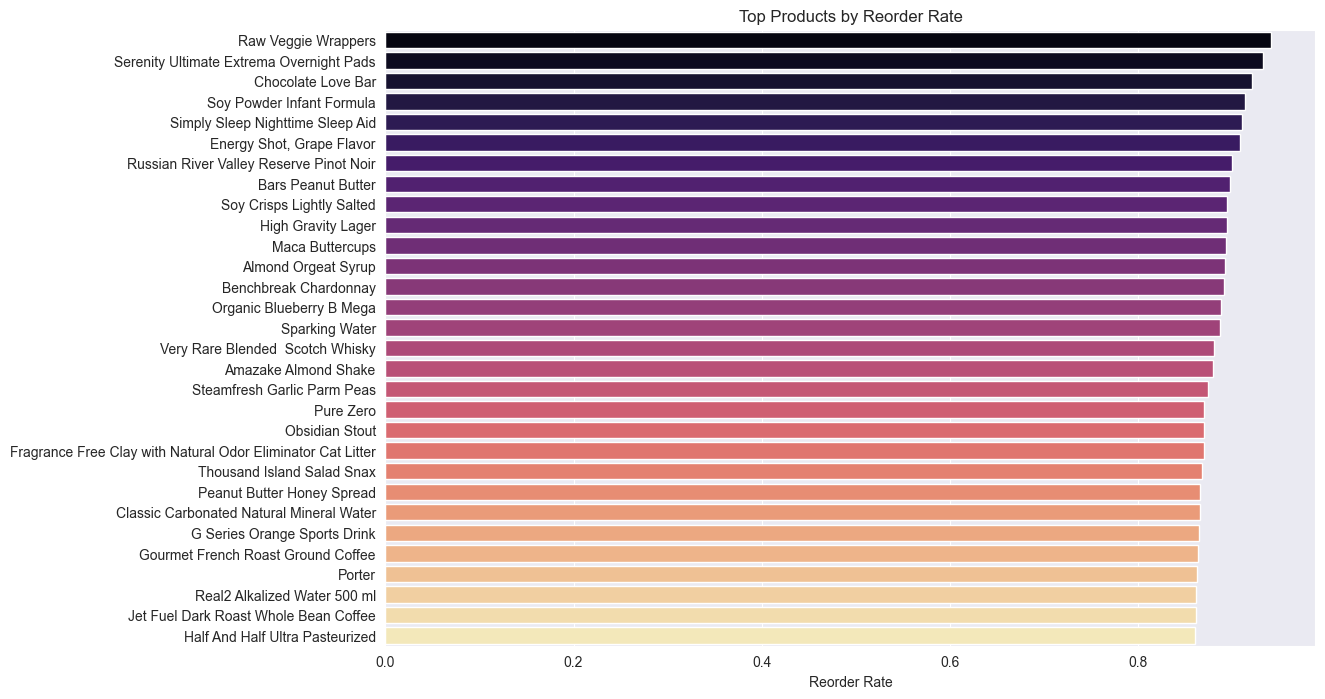

In [55]:
product_counts = df.groupby("product_name")["reordered"].size()
threshold = product_counts.quantile(0.25)
print("threshold value :", threshold)

product_loyalty = (
    df.groupby("product_name")
      .agg(
          total=("reordered", "size"),
          reordered=("reordered", "sum")
      )
      .query("total >= @threshold")
      .assign(reorder_rate=lambda x: x["reordered"] / x["total"])
      .sort_values("reorder_rate", ascending=False)
      .head(30)
      .reset_index()
)
plt.figure(figsize=(12,8))
sns.barplot(
    data=product_loyalty,
    y="product_name",
    x="reorder_rate",
    palette="magma"
)
plt.title("Top Products by Reorder Rate")
plt.xlabel("Reorder Rate")
plt.ylabel("")
plt.show()

In [56]:
import plotly.express as px

fig = px.scatter(
    product_loyalty,
    x="total",
    y="reorder_rate",
    size="total",
    color="reorder_rate",
    hover_name="product_name",
    color_continuous_scale="magma",
    size_max=50,
)

fig.update_layout(
    title="Products: Reorder Rate vs Total Orders",
    xaxis_title="Total Orders",
    yaxis_title="Reorder Rate",
    yaxis=dict(range=[0.6, 1]),
    xaxis_type="log"
)

fig.show()

    ### AXIS 3 — Loyalty × Time
#### When is loyalty most evident ?

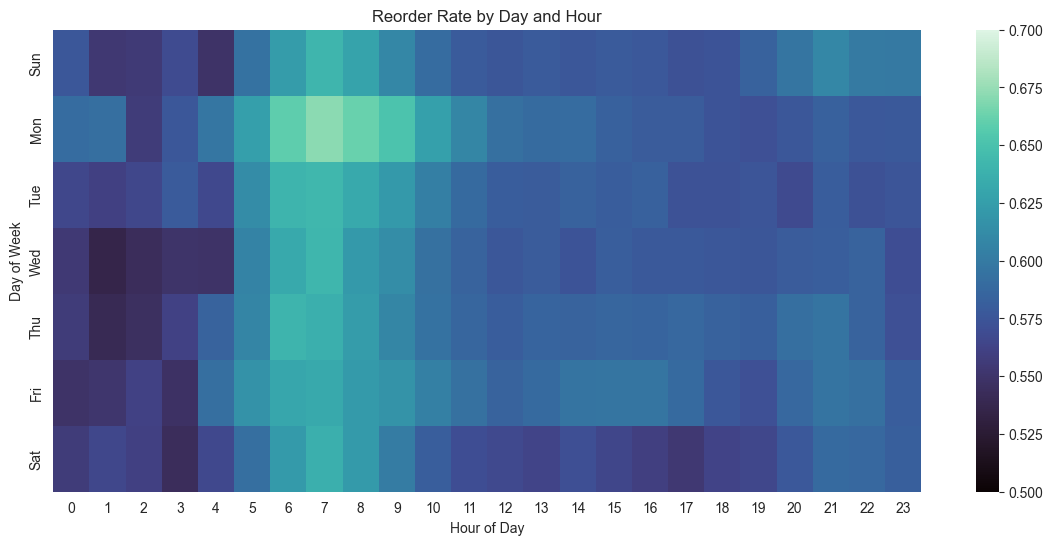

In [57]:
temporal_loyalty = (
    df.groupby(["order_dow", "order_hour_of_day"])
      .agg(
          total=("reordered", "size"),
          reordered=("reordered", "sum")
      )
      .assign(reorder_rate=lambda x: x["reordered"] / x["total"])
      .reset_index()
)

pivot_loyalty = temporal_loyalty.pivot(
    index="order_dow",
    columns="order_hour_of_day",
    values="reorder_rate"
)

day_labels = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
pivot_loyalty.index = day_labels
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    pivot_loyalty,cmap="mako", vmin=0.5, vmax=0.7
)

plt.title("Reorder Rate by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

#### Which products are repurchased at specific times?

C:\Users\natha\AppData\Local\Temp\ipykernel_21972\2230767716.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




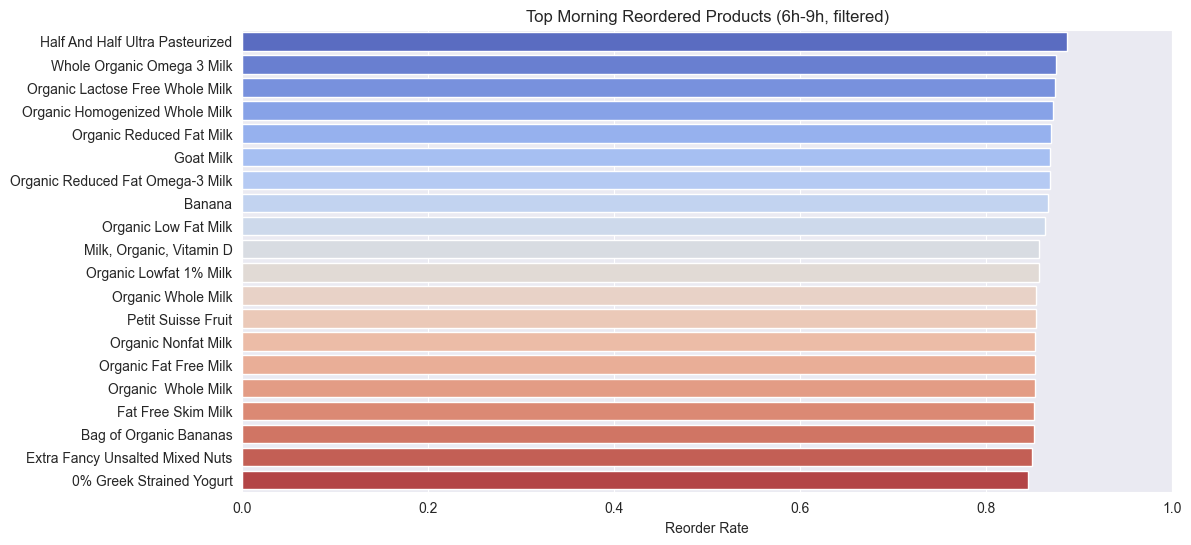

In [58]:
morning = df[(df["order_hour_of_day"] >= 6) & (df["order_hour_of_day"] <= 9)]

morning_loyalty = (
    morning.groupby("product_name")
    .agg(
        total_orders=("reordered", "size"),
        morning_reorders=("reordered", "sum"),
        n_users=("user_id", "nunique")
    )
    .query("total_orders >= 500 and n_users >= 10")
    .assign(reorder_rate=lambda x: x["morning_reorders"] / x["total_orders"])
    .sort_values("reorder_rate", ascending=False)
    .head(20)
    .reset_index()
)

# Graphique
plt.figure(figsize=(12,6))
sns.barplot(
    data=morning_loyalty,
    y="product_name",
    x="reorder_rate",
    palette="coolwarm"
)
plt.title("Top Morning Reordered Products (6h-9h, filtered)")
plt.xlabel("Reorder Rate")
plt.ylabel("")
plt.xlim(0,1)
plt.show()

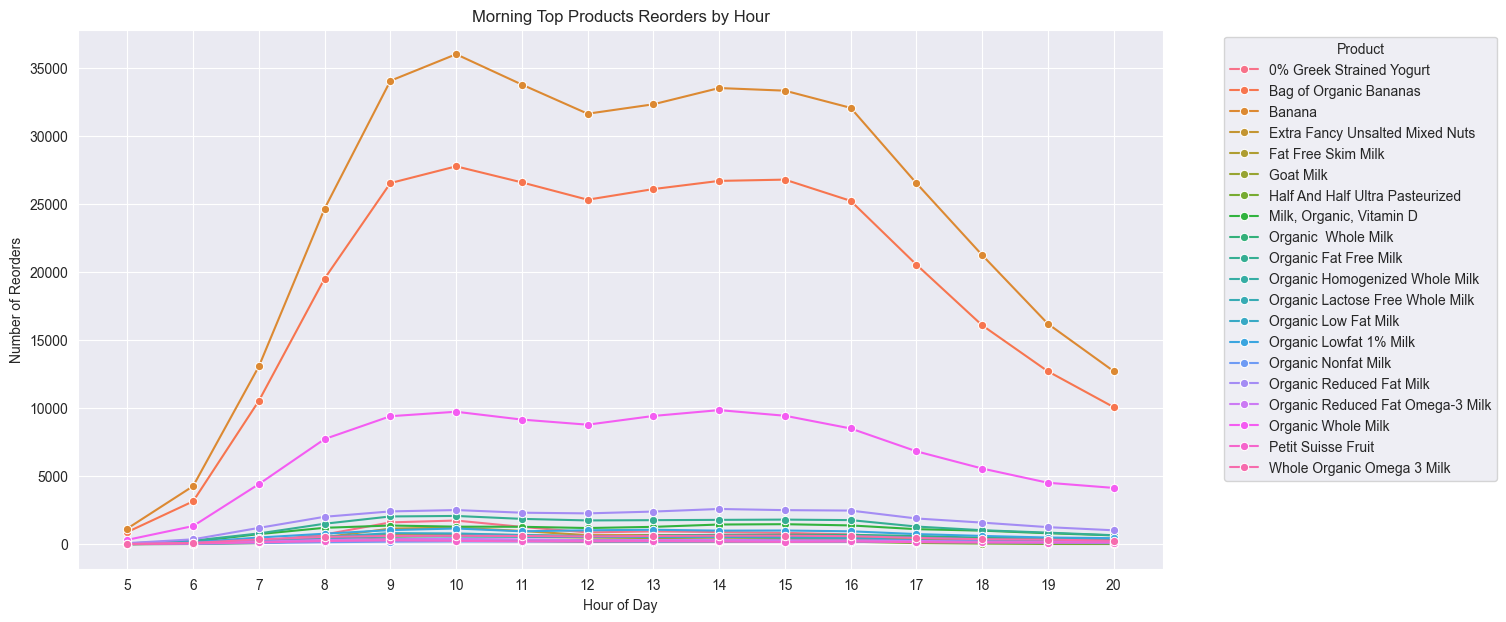

In [59]:
top_products = morning_loyalty["product_name"].tolist()

morning_extended = df[
    (df["order_hour_of_day"] >= 5) & (df["order_hour_of_day"] <= 20) &
    (df["product_name"].isin(top_products)) &
    (df["reordered"] == 1)
]

temporal_loyalty = (
    morning_extended.groupby(["product_name", "order_hour_of_day"])
    .size()
    .reset_index(name="reorders_count")
)

plt.figure(figsize=(14,7))
sns.lineplot(
    data=temporal_loyalty,
    x="order_hour_of_day",
    y="reorders_count",
    hue="product_name",
    marker="o"
)
plt.title("Morning Top Products Reorders by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Reorders")
plt.xticks(range(5,21))
plt.legend(title="Product", bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

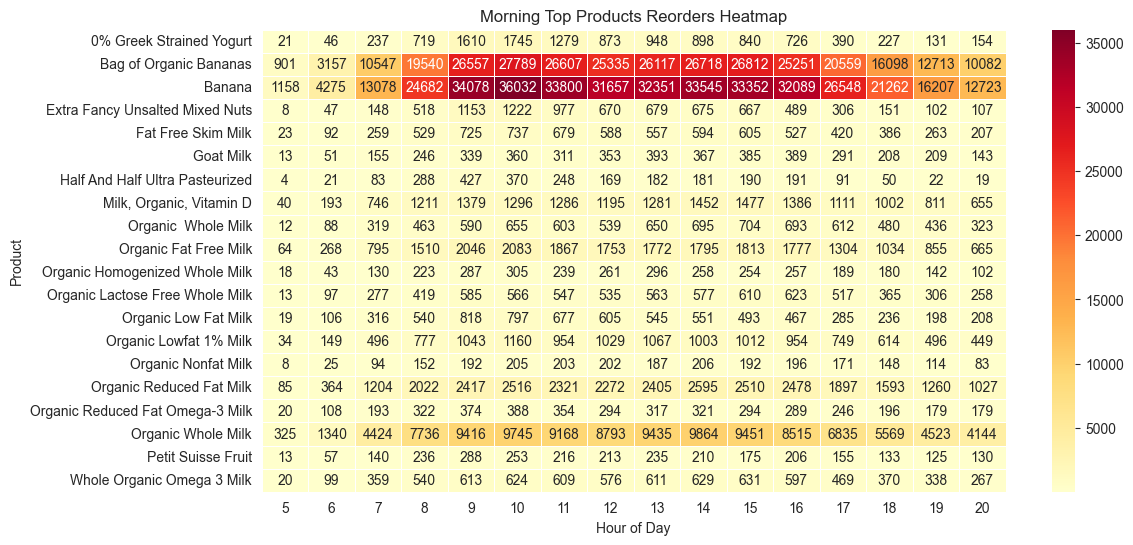

In [60]:
pivot = temporal_loyalty.pivot(
    index="product_name",
    columns="order_hour_of_day",
    values="reorders_count"
)

plt.figure(figsize=(12,6))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    linewidths=0.5,
    annot=True,
    fmt="d"
)
plt.title("Morning Top Products Reorders Heatmap")
plt.xlabel("Hour of Day")
plt.ylabel("Product")
plt.show()

In [61]:
df.reordered.value_counts(normalize=True)

reordered
1    0.590062
0    0.409938
Name: proportion, dtype: float64

### We are now looking on the frequency of the customers

A customer is considered frequent based on: Total numbers of orders, Average purchase time frequency and regularity over time

In [62]:
# Frequency is not a single number, but a profile
# Several complementary metrics can be defined:
client_freq = (
    df.groupby("user_id")
      .agg(
          n_orders=("order_id", "nunique"),
          avg_days_between_orders=("days_since_prior_order", "mean"),
          total_items=("product_id", "count"),
          avg_basket_size=("product_id", lambda x: x.count() / x.nunique())
      )
      .reset_index()
)

#### Are there natural types of customers based on their frequency ?

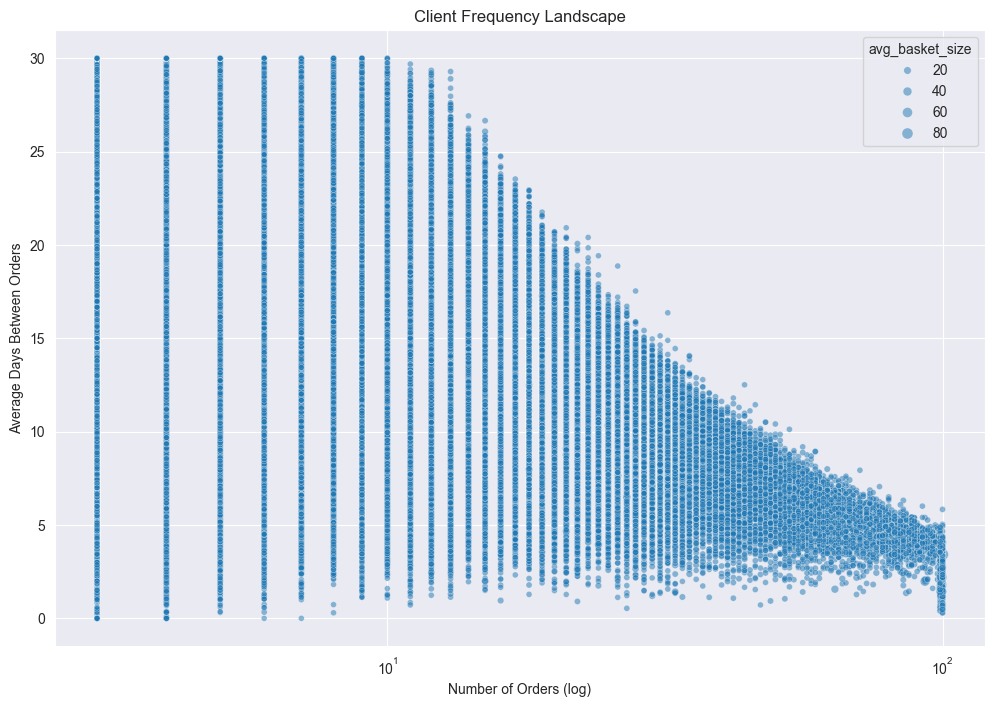

In [63]:
plt.figure(figsize=(12,8))
sns.scatterplot(
    data=client_freq,
    x="n_orders",
    y="avg_days_between_orders",
    size="avg_basket_size",
    alpha=0.5
)
plt.xscale("log")
plt.title("Client Frequency Landscape")
plt.xlabel("Number of Orders (log)")
plt.ylabel("Average Days Between Orders")
plt.show()

#### Do regular customers have specific schedules ?

In [64]:
threshold = client_freq["n_orders"].quantile(0.75)
frequent_users = client_freq.query("n_orders >= @threshold")["user_id"]

df["client_type"] = df["user_id"].isin(frequent_users).map(
    {True: "Frequent", False: "Occasional"}
)

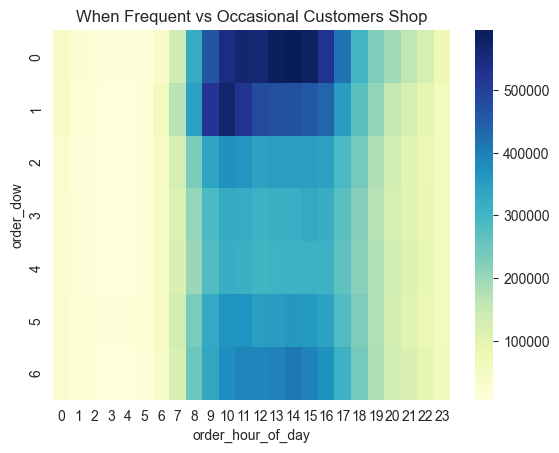

In [65]:
heat = (
    df.groupby(["client_type", "order_dow", "order_hour_of_day"])
      .size()
      .reset_index(name="count")
)

pivot = heat.pivot_table(
    index="order_dow",
    columns="order_hour_of_day",
    values="count",
    aggfunc="sum"
)

sns.heatmap(pivot, cmap="YlGnBu")
plt.title("When Frequent vs Occasional Customers Shop")
plt.show()

#### How many customers become loyal? How many drop out?

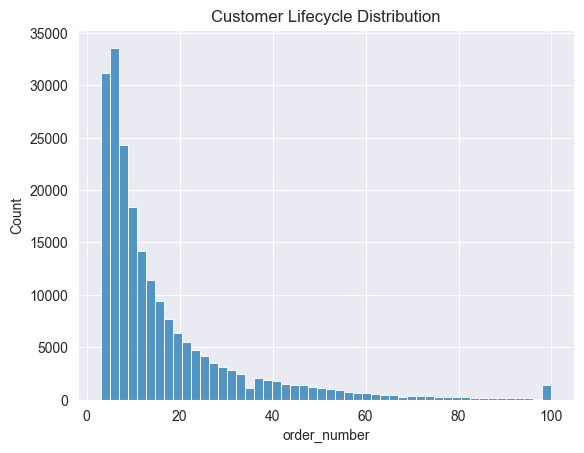

In [66]:
df_last_order = df.groupby("user_id")["order_number"].max().reset_index()

sns.histplot(df_last_order["order_number"], bins=50)
plt.title("Customer Lifecycle Distribution")
plt.show()

#### Do frequent customers buy the same products ?

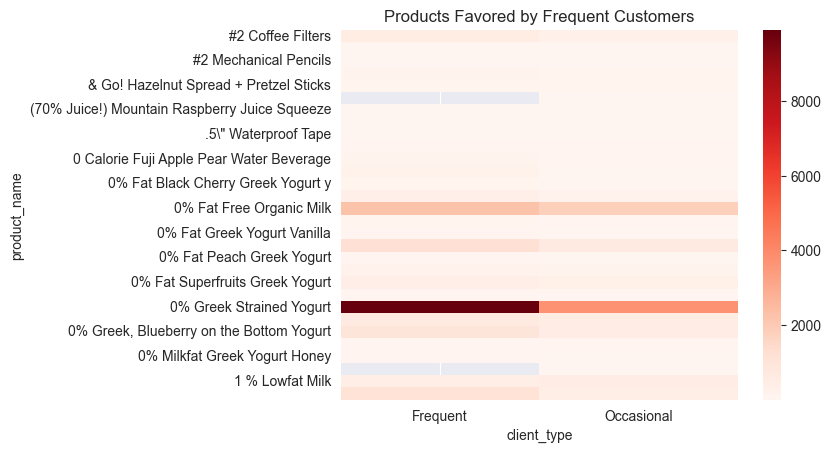

In [67]:
prod_freq = (
    df.groupby(["product_name", "client_type"])
      .size()
      .reset_index(name="count")
)

pivot = prod_freq.pivot(
    index="product_name",
    columns="client_type",
    values="count"
)

sns.heatmap(pivot.head(30), cmap="Reds")
plt.title("Products Favored by Frequent Customers")
plt.show()

#### Do frequent customers buy more or less each time they visit?

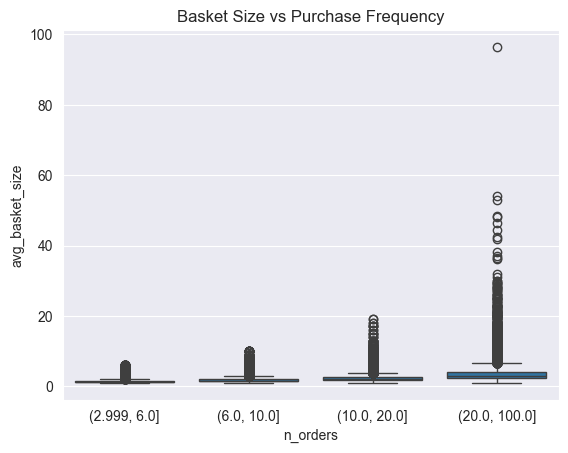

In [68]:
sns.boxplot(
    data=client_freq,
    x=pd.qcut(client_freq["n_orders"], 4),
    y="avg_basket_size"
)
plt.title("Basket Size vs Purchase Frequency")
plt.show()

In [69]:
df['aisle'].nunique()

134

In [70]:
df['department'].nunique()

21

In [71]:
df['product_name'].nunique()

49685

In [ ]:
df['department'].value_counts().plot(kind='bar', color='skyblue', figsize=(10,6), rot=45)
plt.xlabel("Number of products")
plt.ylabel("Department")
plt.show()

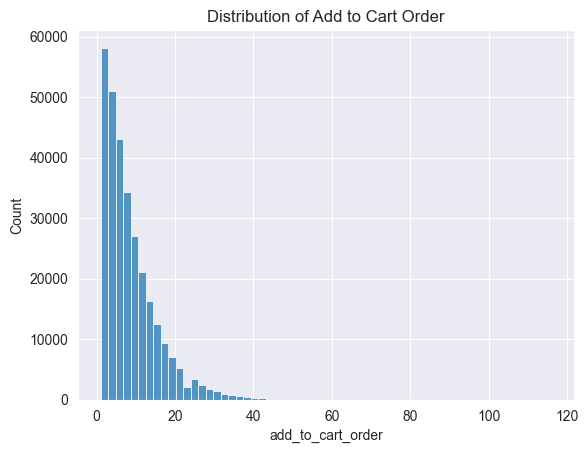

In [30]:
sns.histplot(
    x="add_to_cart_order",
    data=df.sample(300_000, random_state=42),
    bins=60,
    kde=False
)
plt.title("Distribution of Add to Cart Order")
plt.show()

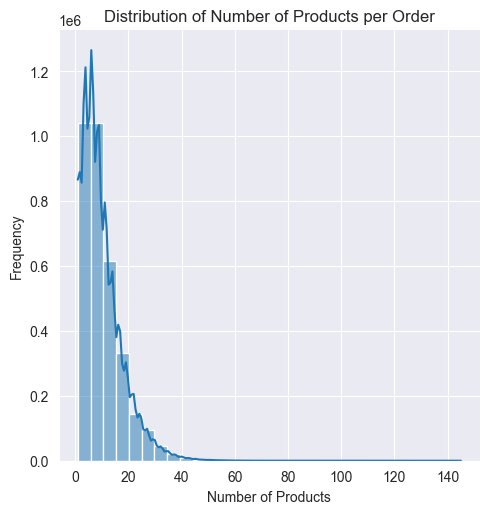

In [32]:
sns.displot(df.groupby('order_id').size(), bins=30, kde=True)
plt.title("Distribution of Number of Products per Order")
plt.xlabel("Number of Products")
plt.ylabel("Frequency")
plt.show()

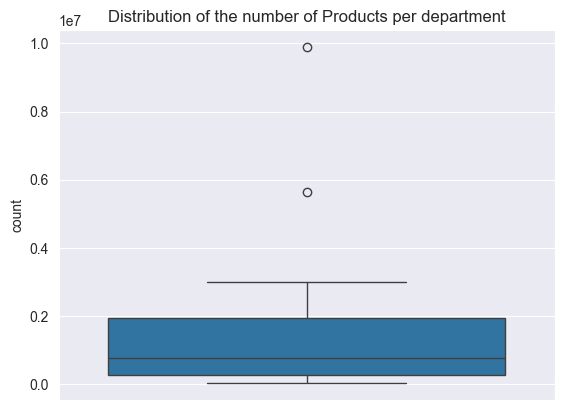

In [33]:
sns.boxplot(
    y=df['department'].value_counts()
)
plt.title("Distribution of the number of Products per department")
plt.show()

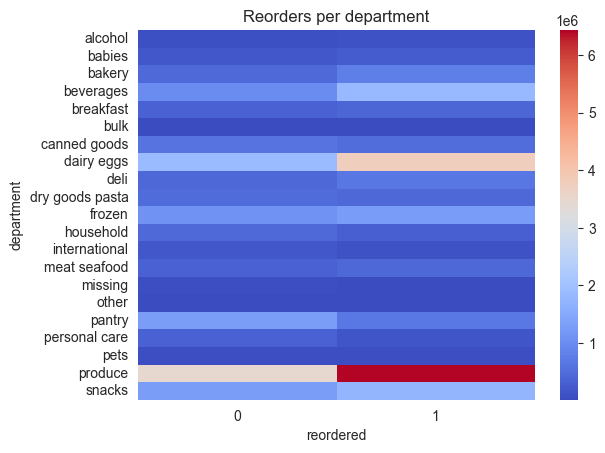

In [34]:
pivot = pd.crosstab(df['department'], df['reordered'])

sns.heatmap(pivot, cmap='coolwarm')
plt.title("Reorders per department")
plt.show()

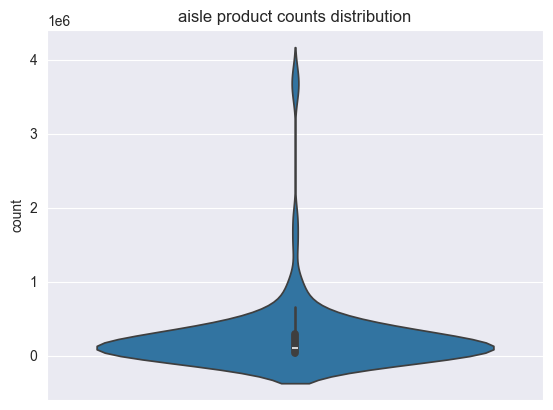

In [35]:
sns.violinplot(y=df['aisle'].value_counts())
plt.title("aisle product counts distribution")
plt.show()

### Reorder rate = average of reordered items

C:\Users\natha\AppData\Local\Temp\ipykernel_21972\4043827248.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



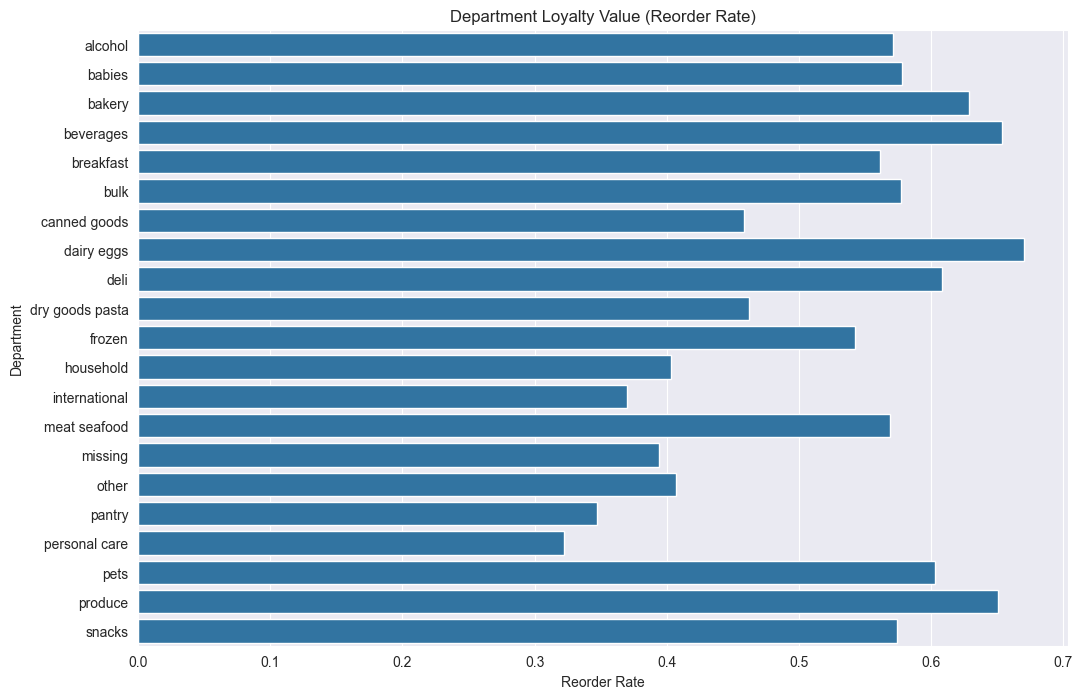

In [36]:
dept_reorder = (
    df
    .groupby('department')['reordered']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))
sns.barplot(x=dept_reorder.values, y=dept_reorder.index)
plt.title("Department Loyalty Value (Reorder Rate)")
plt.xlabel("Reorder Rate")
plt.ylabel("Department")
plt.show()


###  Average number of items per order by department

C:\Users\natha\AppData\Local\Temp\ipykernel_21972\2020811667.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



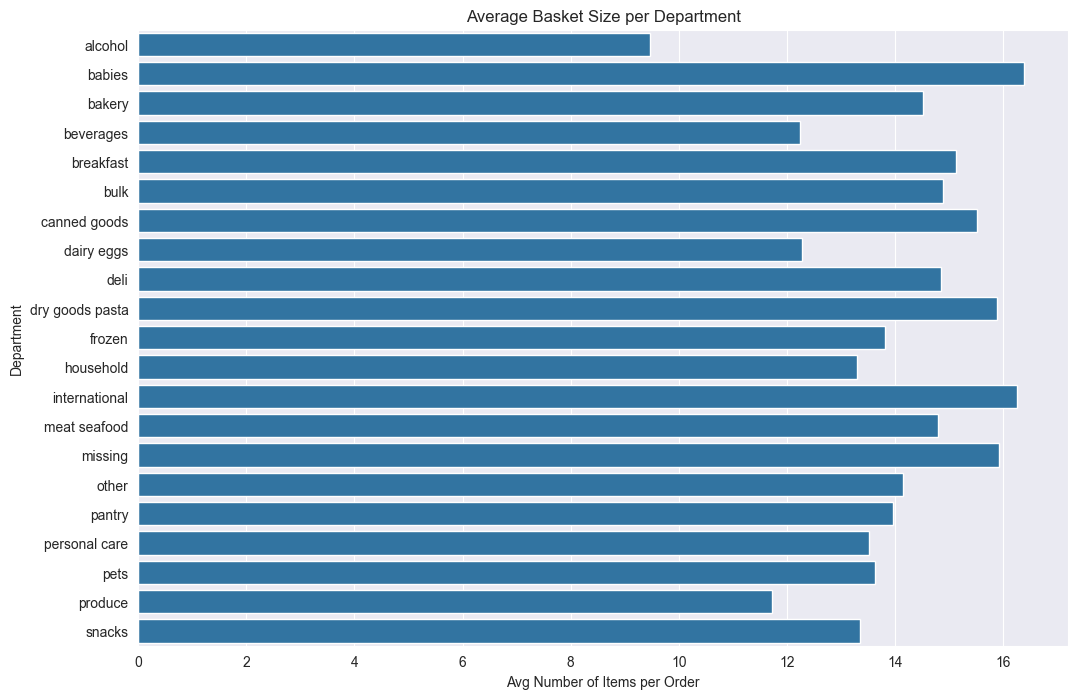

In [37]:
basket_size = df.groupby('order_id')['product_id'].count()

dept_basket = (
    df[['order_id', 'department']]
    .drop_duplicates()
    .merge(basket_size, on='order_id')
    .groupby('department')['product_id']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))
sns.barplot(x=dept_basket.values, y=dept_basket.index)
plt.title("Average Basket Size per Department")
plt.xlabel("Avg Number of Items per Order")
plt.ylabel("Department")
plt.show()

###  Average order per user

C:\Users\natha\AppData\Local\Temp\ipykernel_21972\3173529197.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\natha\AppData\Local\Temp\ipykernel_21972\3173529197.py:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



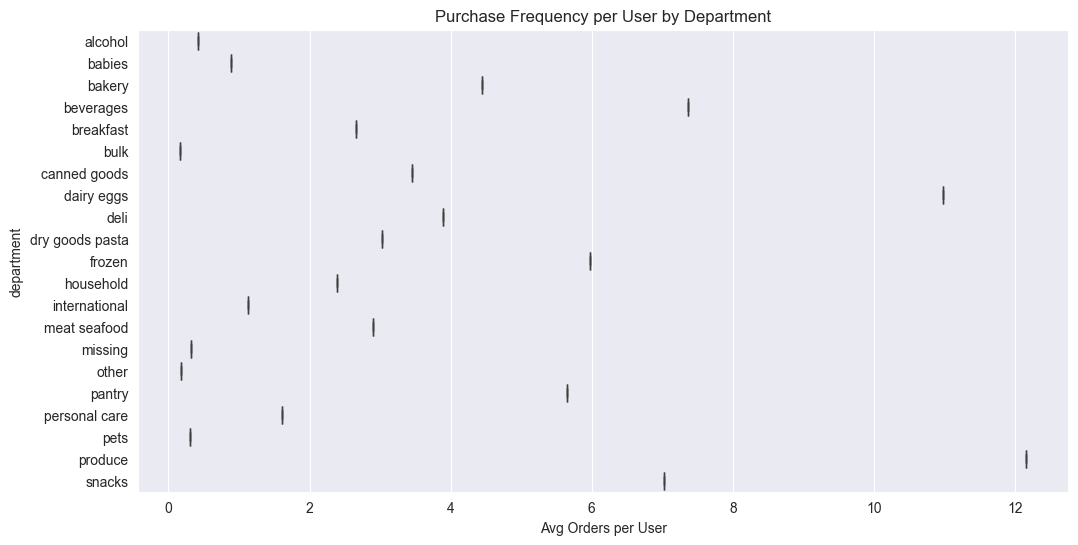

In [38]:
user_orders = (
    df[['user_id', 'order_id', 'department']]
    .drop_duplicates()
    .groupby(['department', 'user_id'])
    .count()
    .groupby('department')
    .mean()
    .sort_values('order_id', ascending=False)
)

plt.figure(figsize=(12,6))
sns.boxplot(data=user_orders, x='order_id', y=user_orders.index)
plt.title("Purchase Frequency per User by Department")
plt.xlabel("Avg Orders per User")
plt.show()

### Average basket size when the department is present vs global size

C:\Users\natha\AppData\Local\Temp\ipykernel_21972\1947765237.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



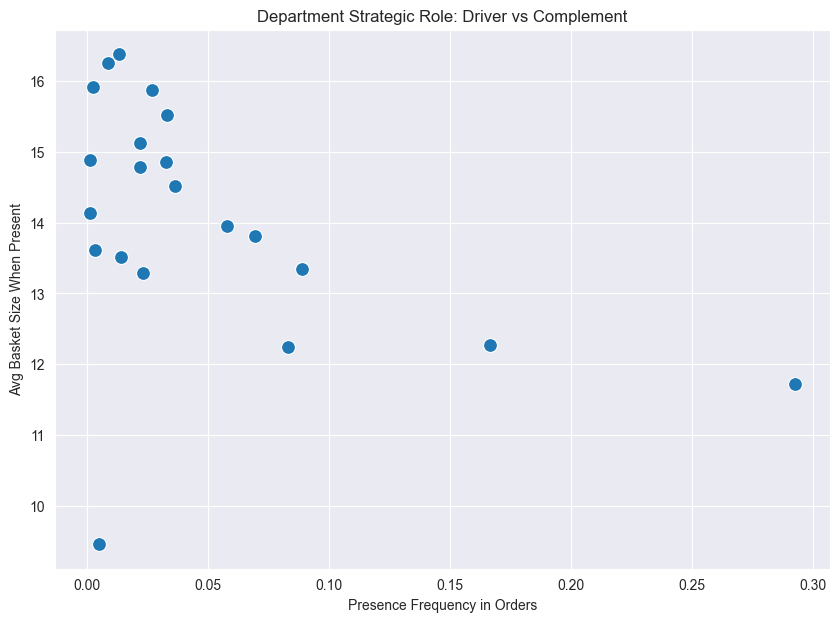

In [39]:
dept_orders = (
    df[['order_id', 'department']]
    .drop_duplicates()
)

basket_size_df = basket_size.reset_index(name='basket_size')

dept_driver = (
    dept_orders
    .merge(basket_size_df, on='order_id')
    .groupby('department')['basket_size']
    .mean()
    .sort_values(ascending=False)
)

dept_freq = df['department'].value_counts(normalize=True)

driver_df = pd.DataFrame({
    'freq': dept_freq,
    'basket_size': dept_driver
}).dropna()

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=driver_df,
    x='freq',
    y='basket_size',
    s=100
)

plt.title("Department Strategic Role: Driver vs Complement")
plt.xlabel("Presence Frequency in Orders")
plt.ylabel("Avg Basket Size When Present")
plt.show()

### Final value graph with all value dimensions aggregated

C:\Users\natha\AppData\Local\Temp\ipykernel_21972\2949285012.py:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\natha\AppData\Local\Temp\ipykernel_21972\2949285012.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\natha\AppData\Local\Temp\ipykernel_21972\2949285012.py:30: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



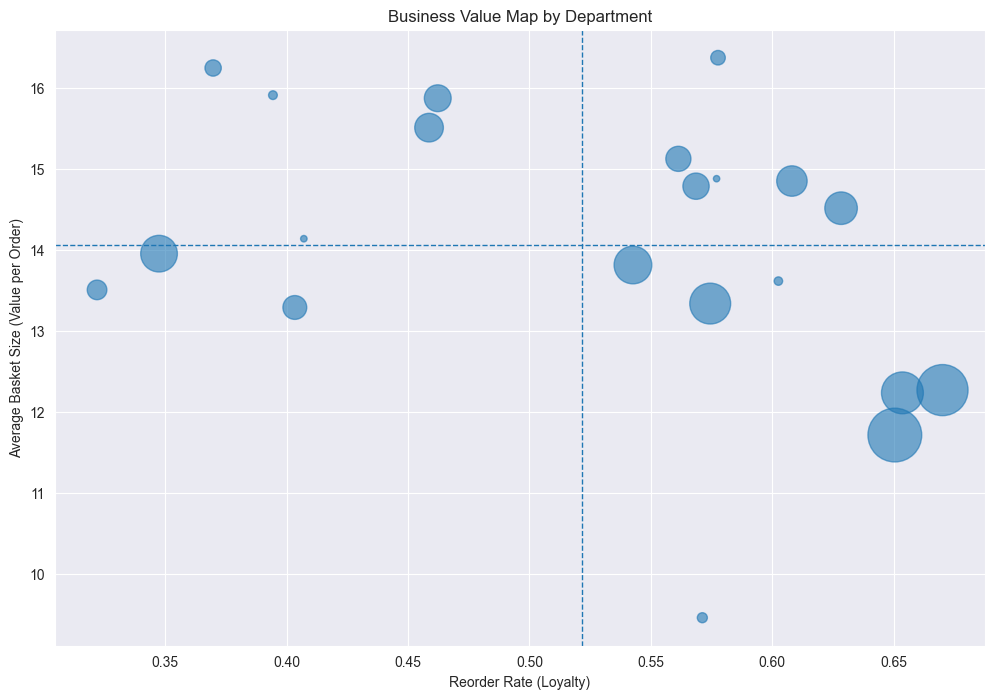

In [40]:
import matplotlib.pyplot as plt

# 1. Reorder rate per department (customer loyalty)
reorder_rate = (
    df
    .groupby('department')['reordered']
    .mean()
)

# 2. Basket size per department (value per order)
basket_size = (
    df
    .groupby('order_id')['product_id']
    .count()
    .reset_index(name='basket_size')
)

dept_basket = (
    df[['order_id', 'department']]
    .drop_duplicates()
    .merge(basket_size, on='order_id')
    .groupby('department')['basket_size']
    .mean()
)

# 3. Presence frequency per department (engagement)
dept_freq = (
    df[['order_id', 'department']]
    .drop_duplicates()
    .groupby('department')
    .size()
)

# 4. Final value DataFrame
value_df = pd.DataFrame({
    'reorder_rate': reorder_rate,
    'avg_basket_size': dept_basket,
    'order_freq': dept_freq
}).dropna()

# Normalize bubble sizes for better visualization
value_df['bubble_size'] = (
    value_df['order_freq'] / value_df['order_freq'].max()
) * 1500

plt.figure(figsize=(12,8))

plt.scatter(
    value_df['reorder_rate'],
    value_df['avg_basket_size'],
    s=value_df['bubble_size'],
    alpha=0.6
)

plt.xlabel("Reorder Rate (Loyalty)")
plt.ylabel("Average Basket Size (Value per Order)")
plt.title("Business Value Map by Department")

plt.axhline(value_df['avg_basket_size'].mean(), linestyle='--', linewidth=1)
plt.axvline(value_df['reorder_rate'].mean(), linestyle='--', linewidth=1)

plt.show()

This graph summarises the business value of departments according to their ability to build customer loyalty, increase basket size and structure purchase frequency. It identifies long-term value drivers independently of prices. This value map shows that business performance depends on a balance between departments that generate recurring revenue and departments that generate value per order. The growth drivers differ depending on the quadrant.

TOP Right - Value Champions
- High loyalty and high value per order and High frequency

TOP Left - Loyal Niches
- Big Basket Size but low frequency

BOTTOM Right - Popular Commodities
- High frequency but low basket size

BOTTOM Left - Low Value
- Low loyalty, low basket size, low frequency

